# Isolation Forest

Build an unsupervised model that separates benign from non-benign packets.

Isolation Forest is an unsupervised anomaly detection method. Instead of forming clusters, it builds many random isolation trees. Points that can be isolated using fewer splits are considered more unusual. This makes the method useful for this project because attack packets are expected to be a small minority of the sample.

For this Phase 2 detector, the model is trained on packet-level features only. Labels are not used during training. After training, each packet receives an anomaly score, and packets with scores above a selected threshold are marked as initial alerts.


## Setup, load metadata and sampled packet dataset


In [36]:
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

METADATA_FILE_NAME = "packet_sample_seed1.metadata.json"

## load packet dataset and metadata
PROJECT_ROOT = Path("..")
META_PATH = PROJECT_ROOT / "data" / "samples" / METADATA_FILE_NAME

with open(META_PATH, "r") as f:
    metadata = json.load(f)

DATA_PATH = PROJECT_ROOT / metadata["output_path"]
df = pd.read_csv(DATA_PATH)

print(df.shape)
df.head()


(205041, 138)


,stream,src_mac,dst_mac,src_ip,dst_ip,src_port,dst_port,inter_arrival_time,time_since_previously_displayed_frame,port_class_dst,...,med_p,average_p,var_p,q3_p,q1_p,iqr_p,l3_ip_dst_count,attack_type,binary_label,source_file
0,3308,ac:17:02:05:34:27,3c:18:a0:41:c3:a0,192.168.137.41,109.95.152.66,38816,443,2109.894808,0.000185,1,...,12.0,196.00,423167.578947,19.0,12.0,7.0,9.0,Benign,benign,BenignTraffic.csv
1,7463,3c:18:a0:41:c3:a0,ac:17:02:05:34:27,157.249.81.141,192.168.137.41,443,60200,4848.002092,0.000290,3,...,15.5,58.65,10582.239474,32.0,12.0,20.0,9.0,Benign,benign,BenignTraffic.csv
2,3000,ac:17:02:05:34:27,3c:18:a0:41:c3:a0,192.168.137.41,157.249.81.141,54061,443,1901.971732,0.003855,1,...,19.5,33.35,2097.081579,28.0,12.0,16.0,9.0,Benign,benign,BenignTraffic.csv
3,27,Amazon Echo Show,Amazon Echo Dot 2,192.168.137.172,192.168.137.58,55444,55444,3902.830519,0.003104,3,...,18.0,18.00,0.000000,18.0,18.0,0.0,50.0,Benign,benign,BenignTraffic.csv
4,0,3c:18:a0:41:c3:a0,Arlo Q Indoor Camera,99.81.244.93,192.168.137.175,443,56891,23.178632,0.000001,3,...,1460.0,1242.80,502105.431579,1460.0,1460.0,0.0,3.0,Benign,benign,BenignTraffic.csv


In [37]:
## check class imbalance
BINARY_COL = "binary_label"
ATTACK_COL = "attack_type"

print(df[BINARY_COL].value_counts())
print()
print(df[ATTACK_COL].value_counts())

## Create numeric labels for evaluation only.
## These labels are not used to train Isolation Forest.
y_true = df[BINARY_COL].map({
    "benign": 0,
    "attack": 1
}).to_numpy()


binary_label
benign    200000
attack      5041
Name: count, dtype: int64

attack_type
Benign             200000
DNS Spoofing         3178
DDoS-HTTP Flood       833
Brute Force           404
DoS-HTTP Flood        364
XSS                   262
Name: count, dtype: int64


## Data Preprocessing




### Isolation Forest feature selection

The feature selection step is kept similar to the K-Means notebook. I remove label columns and text-like identifier columns such as IP addresses, MAC addresses, host names, URI strings, and user agents. These fields are useful for network interpretation, but directly using them as numeric model inputs would either fail or create artificial patterns.

Only numeric packet-level features are used for the first Isolation Forest implementation. This keeps the model simple and makes the results easier to explain.


In [38]:
# Basic packet behavior features
base_features = [
    "time_since_previously_displayed_frame",
    "port_class_dst",
    "l4_tcp",
    "l4_udp",
    "ttl",
    "eth_size",
    "tcp_window_size",
    "payload_entropy",
    "payload_length",
    "jitter",
    "dns_len_qry",
    "dns_interval",
    "dns_len_ans",
    "http_content_len",
    "http_response_code",
    "handshake_cipher_suites_length",
    "handshake_extensions_length",
    "handshake_sig_hash_alg_len",
    "icmp_data_size",
    "l3_ip_dst_count",
    "average_p",
    "var_p",
    "iqr_p"
]

# Keep useful short-term and longer-term traffic statistics
rolling_features = []

for group in ["stream", "src_ip", "channel"]:
    rolling_features += [f"{group}_{window}_count" for window in [1, 5, 30]]
    rolling_features += [f"{group}_{window}_{stat}" for window in [5, 30] for stat in ["mean", "var"]]

rolling_features += [
    "stream_jitter_5_mean",
    "stream_jitter_5_var",
    "stream_jitter_30_mean",
    "stream_jitter_30_var"
]

feature_cols = [col for col in base_features + rolling_features if col in df.columns]
X_raw = df[feature_cols].apply(pd.to_numeric, errors="coerce").copy()

print("Initial selected features:", X_raw.shape[1])

Initial selected features: 48


### Isolation Forest feature engineering

In [39]:
src_port = pd.to_numeric(df["src_port"], errors="coerce").fillna(-1)
dst_port = pd.to_numeric(df["dst_port"], errors="coerce").fillna(-1)

packet_size = pd.to_numeric(df["eth_size"], errors="coerce").replace(0, np.nan)
payload_size = pd.to_numeric(df["payload_length"], errors="coerce").fillna(0)

dns_query = pd.to_numeric(df["dns_len_qry"], errors="coerce").fillna(0)
dns_answer = pd.to_numeric(df["dns_len_ans"], errors="coerce").fillna(0)

http_length = pd.to_numeric(df["http_content_len"], errors="coerce").fillna(0)
http_code = pd.to_numeric(df["http_response_code"], errors="coerce").fillna(0)

tls_length = pd.to_numeric(df["handshake_extensions_length"], errors="coerce").fillna(0)
icmp_size = pd.to_numeric(df["icmp_data_size"], errors="coerce").fillna(-1)

# Packet and protocol indicators
X_raw["payload_ratio"] = (payload_size / packet_size).clip(0, 1).fillna(0)
X_raw["has_payload"] = (payload_size > 0).astype(int)

X_raw["uses_dns_port"] = ((src_port == 53) | (dst_port == 53)).astype(int)
X_raw["has_dns_data"] = ((dns_query > 0) | (dns_answer > 0)).astype(int)

X_raw["uses_http_port"] = ((src_port == 80) | (dst_port == 80)).astype(int)
X_raw["uses_https_port"] = ((src_port == 443) | (dst_port == 443)).astype(int)
X_raw["has_http_data"] = ((http_length > 0) | (http_code > 0)).astype(int)

X_raw["has_tls_handshake"] = (tls_length > 0).astype(int)
X_raw["is_icmp"] = (icmp_size >= 0).astype(int)

X_raw["src_port_ephemeral"] = (src_port >= 49152).astype(int)
X_raw["dst_port_ephemeral"] = (dst_port >= 49152).astype(int)

# burst-ratio features
def burst_ratio(short_col, long_col):
    short_count = pd.to_numeric(df[short_col], errors="coerce").fillna(0)
    long_count = pd.to_numeric(df[long_col], errors="coerce").fillna(0)

    recent_rate = short_count / 5
    previous_rate = (long_count - short_count).clip(lower=0) / 25

    return (recent_rate + 1) / (previous_rate + 1)

for group in ["stream", "src_ip", "channel"]:
    X_raw[f"{group}_burst_ratio"] = burst_ratio(f"{group}_5_count", f"{group}_30_count")

print("Features after engineering:", X_raw.shape[1])
X_raw.head()

Features after engineering: 62


,time_since_previously_displayed_frame,port_class_dst,l4_tcp,l4_udp,ttl,eth_size,tcp_window_size,payload_entropy,payload_length,jitter,...,uses_http_port,uses_https_port,has_http_data,has_tls_handshake,is_icmp,src_port_ephemeral,dst_port_ephemeral,stream_burst_ratio,src_ip_burst_ratio,channel_burst_ratio
0,0.000185,1,1,0,64,60,0,0.000000,0,0.000185,...,0,1,0,0,0,0,0,3.800000,1.179039,3.800000
1,0.000290,3,1,0,49,66,65024,0.000000,0,0.000290,...,0,1,0,0,0,0,1,2.800000,1.085714,1.051051
2,0.003855,1,1,0,64,74,14600,0.000000,0,947.623914,...,0,1,0,0,0,1,0,1.200000,1.081081,1.072508
3,0.003104,3,0,1,64,60,0,3.201876,16,0.005255,...,0,0,0,0,0,1,1,2.777778,1.371681,2.826087
4,0.000001,3,1,0,231,66,4415,0.000000,0,0.000001,...,0,1,0,0,0,0,1,1.429706,1.451327,1.429140


### Basic preprocessing

Need to:<br>
&emsp;replace inf values<br>
&emsp;impute missing values with median<br>
&emsp;remove completely empty columns<br>
&emsp;remove constant columns<br>
&emsp;scale features<br>

Missing and infinite values were replaced because packet-level network features can contain undefined values, especially in variance, jitter, and rate-related columns. Median imputation is used because it is simple and less sensitive to extreme values than mean imputation. Constant columns are removed because they do not help the model separate normal and unusual packets.

Isolation Forest is not as sensitive to scaling as K-Means, but I still use standard scaling to keep preprocessing consistent across Phase 2 models and to make the PCA visualization more meaningful.


In [40]:
### Train, test, val split
all_idx = np.arange(len(df))

train_idx, temp_idx = train_test_split(
    all_idx, test_size=0.40, random_state=1, stratify=df[ATTACK_COL]
)

val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, random_state=1, stratify=df.iloc[temp_idx][ATTACK_COL]
)

### Data cleaning
X_clean = X_raw.replace([np.inf, -np.inf], np.nan).copy()

# Missing variance or jitter usually means there were not enough earlier packets
zero_fill_cols = [col for col in X_clean.columns if col.endswith("_var") or "jitter" in col]
X_clean[zero_fill_cols] = X_clean[zero_fill_cols].fillna(0)

X_train_df = X_clean.iloc[train_idx].copy()
X_val_df = X_clean.iloc[val_idx].copy()
X_test_df = X_clean.iloc[test_idx].copy()

### Remove unusable columns using only the training set
drop_cols = [
    col for col in X_train_df.columns
    if X_train_df[col].isna().all() or X_train_df[col].nunique(dropna=True) <= 1
]
X_train_df = X_train_df.drop(columns=drop_cols)
X_val_df = X_val_df.drop(columns=drop_cols)
X_test_df = X_test_df.drop(columns=drop_cols)

### Apply log transformation
log_cols = []

for col in X_train_df.columns:
    values = X_train_df[col].dropna()

    if len(values) > 0 and values.min() >= 0 and values.nunique() > 2 and abs(values.skew()) > 2:
        log_cols.append(col)

for split in [X_train_df, X_val_df, X_test_df]:
    split[log_cols] = np.log1p(split[log_cols].clip(lower=0))

### Remove highly correlated features
CORRELATED_FEATURE_THRESHOLD = 0.98
correlation = X_train_df.corr(numeric_only=True).abs()
upper_triangle = correlation.where(np.triu(np.ones(correlation.shape), k=1).astype(bool))

correlated_cols = [col for col in upper_triangle.columns if (upper_triangle[col] > CORRELATED_FEATURE_THRESHOLD).any()]

X_train_df = X_train_df.drop(columns=correlated_cols)
X_val_df = X_val_df.drop(columns=correlated_cols)
X_test_df = X_test_df.drop(columns=correlated_cols)

### Impute the missing values
preprocess = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True))
])

X_train = preprocess.fit_transform(X_train_df).astype(np.float32)
X_val = preprocess.transform(X_val_df).astype(np.float32)
X_test = preprocess.transform(X_test_df).astype(np.float32)

y_train = y_true[train_idx]
y_val = y_true[val_idx]
y_test = y_true[test_idx]

### Print preprocessing results
print("Training shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

print("\nPreprocessing summary:")
print("Removed unusable features:", len(drop_cols))
print("Removed correlated features:", len(correlated_cols))
print("Log-transformed features:", len(log_cols))

print("\nAttack counts:")
print("Train:", y_train.sum())
print("Validation:", y_val.sum())
print("Test:", y_test.sum())

Training shape: (123024, 61)
Validation shape: (41008, 61)
Test shape: (41009, 61)

Preprocessing summary:
Removed unusable features: 0
Removed correlated features: 6
Log-transformed features: 45

Attack counts:
Train: 3024
Validation: 1008
Test: 1009


## Tunning

### Tune Isolation Forest hyperparameters

The main Isolation Forest hyperparameters I tune are:

- `n_estimators`: number of trees in the forest. More trees usually give more stable anomaly scores but require more time.
- `max_samples`: number of samples used to build each tree. Smaller values are faster, while larger values may capture more packet variation.
- alert threshold: the percentage of packets marked as anomalous.

Since this is an unsupervised model, labels are not used when fitting the model. I first compare runtime and anomaly-score separation for several model settings. Then I use an expected alert rate near the project sampling design, around 2–3%, to convert anomaly scores into alerts.


In [41]:
n_estimators_values = [200, 400]
max_samples_values = [256, 1024, 4096]
max_features_values = [0.5, 0.75, 1.0]

tuning_results = []

for n_estimators in n_estimators_values:
    for max_samples in max_samples_values:
        for max_features in max_features_values:
            start = time.time()

            model = IsolationForest(
                n_estimators=n_estimators,
                max_samples=max_samples,
                max_features=max_features,
                contamination="auto",
                random_state=1,
                n_jobs=-1
            )

            model.fit(X_train)
            val_scores = -model.score_samples(X_val)

            tuning_results.append({
                "n_estimators": n_estimators,
                "max_samples": max_samples,
                "max_features": max_features,
                "val_pr_auc": average_precision_score(y_val, val_scores),
                "val_roc_auc": roc_auc_score(y_val, val_scores),
                "runtime_sec": time.time() - start
            })

            print(
                f"trees={n_estimators}, samples={max_samples}, features={max_features}, "
                f"PR-AUC={tuning_results[-1]['val_pr_auc']:.4f}"
            )

### Print results
iforest_tuning_df = pd.DataFrame(tuning_results)
iforest_tuning_df = iforest_tuning_df.sort_values(["val_pr_auc", "val_roc_auc"], ascending=False).reset_index(drop=True)
display(iforest_tuning_df)

trees=200, samples=256, features=0.5, PR-AUC=0.1099
trees=200, samples=256, features=0.75, PR-AUC=0.1372
trees=200, samples=256, features=1.0, PR-AUC=0.1289
trees=200, samples=1024, features=0.5, PR-AUC=0.2694
trees=200, samples=1024, features=0.75, PR-AUC=0.2727
trees=200, samples=1024, features=1.0, PR-AUC=0.2713
trees=200, samples=4096, features=0.5, PR-AUC=0.3235
trees=200, samples=4096, features=0.75, PR-AUC=0.3479
trees=200, samples=4096, features=1.0, PR-AUC=0.3316
trees=400, samples=256, features=0.5, PR-AUC=0.1176
trees=400, samples=256, features=0.75, PR-AUC=0.1227
trees=400, samples=256, features=1.0, PR-AUC=0.1285
trees=400, samples=1024, features=0.5, PR-AUC=0.2849
trees=400, samples=1024, features=0.75, PR-AUC=0.2671
trees=400, samples=1024, features=1.0, PR-AUC=0.2711
trees=400, samples=4096, features=0.5, PR-AUC=0.3535
trees=400, samples=4096, features=0.75, PR-AUC=0.3409
trees=400, samples=4096, features=1.0, PR-AUC=0.3414


,n_estimators,max_samples,max_features,val_pr_auc,val_roc_auc,runtime_sec
0,400,4096,0.50,0.353549,0.870255,1.806373
1,200,4096,0.75,0.347876,0.870566,0.970554
2,400,4096,1.00,0.341442,0.871003,1.644410
3,400,4096,0.75,0.340930,0.871238,1.986992
4,200,4096,1.00,0.331632,0.865964,0.785886
5,200,4096,0.50,0.323483,0.863814,0.930948
6,400,1024,0.50,0.284900,0.848776,1.636204
7,200,1024,0.75,0.272683,0.848808,0.876263
8,200,1024,1.00,0.271325,0.849546,0.710735
9,400,1024,1.00,0.271122,0.849601,1.410823


### Select the best hyperparameters

Best n_estimators: 400
Best max_samples: 4096
Best max_features: 0.5
Best validation PR-AUC: 0.35354917001028047
Best validation ROC-AUC: 0.8702549107142856


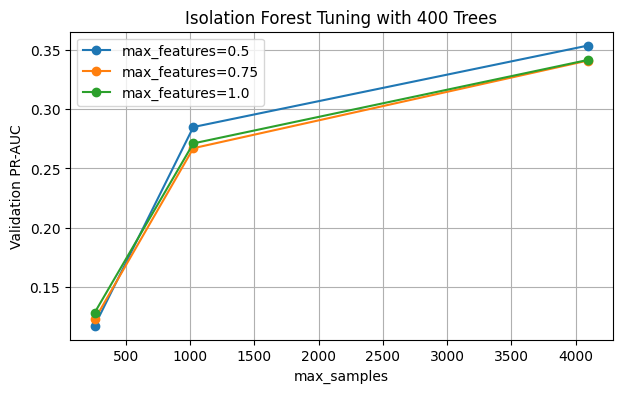

In [42]:
best_row = iforest_tuning_df.iloc[0]

BEST_N_ESTIMATORS = int(best_row["n_estimators"])
BEST_MAX_SAMPLES = int(best_row["max_samples"])
BEST_MAX_FEATURES = float(best_row["max_features"])

print("Best n_estimators:", BEST_N_ESTIMATORS)
print("Best max_samples:", BEST_MAX_SAMPLES)
print("Best max_features:", BEST_MAX_FEATURES)
print("Best validation PR-AUC:", best_row["val_pr_auc"])
print("Best validation ROC-AUC:", best_row["val_roc_auc"])

### plot
plt.figure(figsize=(7, 4))

for max_features in max_features_values:
    temp = iforest_tuning_df[(iforest_tuning_df["n_estimators"] == BEST_N_ESTIMATORS) & (iforest_tuning_df["max_features"] == max_features)].sort_values("max_samples")
    plt.plot(temp["max_samples"], temp["val_pr_auc"], marker="o", label=f"max_features={max_features}")

plt.xlabel("max_samples")
plt.ylabel("Validation PR-AUC")
plt.title(f"Isolation Forest Tuning with {BEST_N_ESTIMATORS} Trees")
plt.legend()
plt.grid(True)
plt.show()

Each candidate model was trained only on the training set. I selected the final hyperparameters using validation PR-AUC because the attack class is highly imbalanced. The best setting used 400 trees, 4096 samples per tree, and 50% of the features.

## Training model

### Train Isolation Forest model


In [43]:
start_train = time.time()

iforest = IsolationForest(
    n_estimators=BEST_N_ESTIMATORS,
    max_samples=BEST_MAX_SAMPLES,
    max_features=BEST_MAX_FEATURES,
    contamination="auto",
    random_state=1,
    n_jobs=-1
)

iforest.fit(X_train)

train_time = time.time() - start_train

print("Training time:", train_time)

Training time: 1.039344072341919


### Generate validation and test anomaly scores

Isolation Forest assigns an anomaly score to every packet. A larger score means the packet is more unusual. The alert threshold is selected using the validation set and then applied unchanged to the test set.

In [44]:
start_score = time.time()

val_scores = -iforest.score_samples(X_val)
test_scores = -iforest.score_samples(X_test)

score_time = time.time() - start_score

print("Validation score range:", val_scores.min(), "to", val_scores.max())
print("Test score range:", test_scores.min(), "to", test_scores.max())
print("Scoring time:", score_time)

Validation score range: 0.36895894663023115 to 0.6429634982476357
Test score range: 0.3687911832978554 to 0.652077397441593
Scoring time: 1.6102557182312012


### Select alert threshold using the validation set

In [45]:
alert_rates = np.arange(0.005, 0.061, 0.005)
threshold_rows = []

for alert_rate in alert_rates:
    threshold = np.quantile(val_scores, 1 - alert_rate)
    val_pred = (val_scores >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_val, val_pred, labels=[0, 1]).ravel()

    threshold_rows.append({
        "alert_rate": alert_rate,
        "threshold": threshold,
        "precision": precision_score(y_val, val_pred, zero_division=0),
        "recall": recall_score(y_val, val_pred, zero_division=0),
        "f1": f1_score(y_val, val_pred, zero_division=0),
        "fpr": fp / (fp + tn),
        "fnr": fn / (fn + tp),
        "tp": tp,
        "fp": fp,
        "fn": fn
    })

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df)

### Select the final threshold
MAX_VAL_FPR = 0.015

valid_thresholds = threshold_df[threshold_df["fpr"] <= MAX_VAL_FPR]

if len(valid_thresholds) == 0:
    valid_thresholds = threshold_df.copy()

best_threshold_row = valid_thresholds.sort_values(["f1", "recall"], ascending=False).iloc[0]

FINAL_THRESHOLD = best_threshold_row["threshold"]

print("Selected alert rate:", best_threshold_row["alert_rate"])
print("Selected threshold:", FINAL_THRESHOLD)
print("Validation precision:", best_threshold_row["precision"])
print("Validation recall:", best_threshold_row["recall"])
print("Validation F1:", best_threshold_row["f1"])
print("Validation FPR:", best_threshold_row["fpr"])

,alert_rate,threshold,precision,recall,f1,fpr,fnr,tp,fp,fn
0,0.005,0.569712,0.781553,0.159722,0.265239,0.001125,0.840278,161,45,847
1,0.010,0.552474,0.615572,0.250992,0.356589,0.003950,0.749008,253,158,755
2,0.015,0.541727,0.508117,0.310516,0.385468,0.007575,0.689484,313,303,695
3,0.020,0.534734,0.425091,0.346230,0.381629,0.011800,0.653770,349,472,659
4,0.025,0.529337,0.368421,0.375000,0.371681,0.016200,0.625000,378,648,630
5,0.030,0.525236,0.325751,0.397817,0.358196,0.020750,0.602183,401,830,607
6,0.035,0.521950,0.291086,0.414683,0.342062,0.025450,0.585317,418,1018,590
7,0.040,0.518646,0.260207,0.423611,0.322386,0.030350,0.576389,427,1214,581
8,0.045,0.516190,0.238895,0.437500,0.309040,0.035125,0.562500,441,1405,567
9,0.050,0.513561,0.223793,0.455357,0.300098,0.039800,0.544643,459,1592,549


Selected alert rate: 0.015
Selected threshold: 0.5417266312555096
Validation precision: 0.5081168831168831
Validation recall: 0.310515873015873
Validation F1: 0.3854679802955665
Validation FPR: 0.007575


### Apply the frozen threshold

In [46]:
val_pred = (val_scores >= FINAL_THRESHOLD).astype(int)
test_pred = (test_scores >= FINAL_THRESHOLD).astype(int)

df_val_result = df.iloc[val_idx].copy()
df_val_result["model"] = "IsolationForest"
df_val_result["anomaly_score"] = val_scores
df_val_result["y_pred"] = val_pred

df_test_result = df.iloc[test_idx].copy()
df_test_result["model"] = "IsolationForest"
df_test_result["anomaly_score"] = test_scores
df_test_result["y_pred"] = test_pred

print("Validation alerts:", val_pred.sum())
print("Test alerts:", test_pred.sum())

Validation alerts: 616
Test alerts: 639


## Evaluation

### Phase 2 evaluation metrics

The project requires Phase 2 packet-level evaluation with precision, recall, F1-score, per-attack detection rate, FPR, FNR, AUC-ROC, and a confusion matrix. The function below keeps the output as one simple table so it can be compared with the K-Means results later.


In [47]:
def evaluate_phase2(y_true, y_pred, scores, model_name, runtime_sec):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    result = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, scores),
        "pr_auc": average_precision_score(y_true, scores),
        "fpr": fp / (fp + tn),
        "fnr": fn / (fn + tp),
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn,
        "alerts": y_pred.sum(),
        "runtime_sec": runtime_sec
    }

    return pd.DataFrame([result])


metrics_df = evaluate_phase2(y_test, test_pred, test_scores, "IsolationForest", train_time + score_time)
display(metrics_df.round(4))

,model,accuracy,precision,recall,f1,roc_auc,pr_auc,fpr,fnr,tp,fp,tn,fn,alerts,runtime_sec
0,IsolationForest,0.9753,0.4961,0.3142,0.3847,0.8655,0.3453,0.008,0.6858,317,322,39678,692,639,2.6496


### Validation and test comparison

In [48]:
val_metrics_df = evaluate_phase2(y_val, val_pred, val_scores, "Validation", train_time + score_time)
test_metrics_df = evaluate_phase2(y_test, test_pred, test_scores, "Test", train_time + score_time)

comparison_df = pd.concat([val_metrics_df, test_metrics_df], ignore_index=True)
display(comparison_df[["model", "precision", "recall", "f1", "roc_auc", "pr_auc", "fpr", "fnr", "alerts"]].round(4))

,model,precision,recall,f1,roc_auc,pr_auc,fpr,fnr,alerts
0,Validation,0.5081,0.3105,0.3855,0.8703,0.3535,0.0076,0.6895,616
1,Test,0.4961,0.3142,0.3847,0.8655,0.3453,0.0080,0.6858,639


### Threshold sensitivity analysis

The threshold was selected using validation data only. The plot shows how precision, recall, F1-score, and false-positive rate change as the alert rate increases. The final threshold was chosen to maximize validation F1 while keeping the validation FPR below 1.5%.


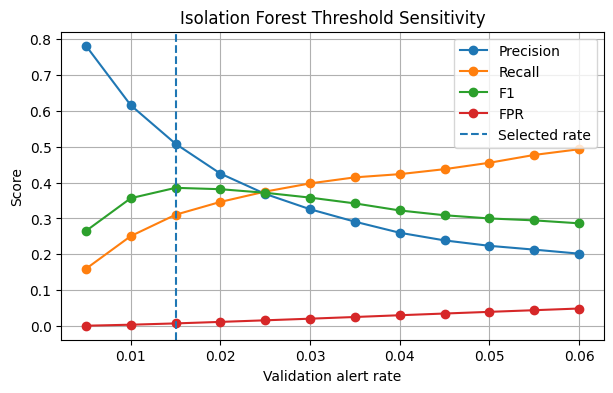

In [49]:
plt.figure(figsize=(7, 4))

plt.plot(threshold_df["alert_rate"], threshold_df["precision"], marker="o", label="Precision")
plt.plot(threshold_df["alert_rate"], threshold_df["recall"], marker="o", label="Recall")
plt.plot(threshold_df["alert_rate"], threshold_df["f1"], marker="o", label="F1")
plt.plot(threshold_df["alert_rate"], threshold_df["fpr"], marker="o", label="FPR")

plt.axvline(best_threshold_row["alert_rate"], linestyle="--", label="Selected rate")

plt.xlabel("Validation alert rate")
plt.ylabel("Score")
plt.title("Isolation Forest Threshold Sensitivity")
plt.legend()
plt.grid(True)
plt.show()

### Results by traffic type

Classification results by traffic type:


,total,correct,incorrect,correct_rate
attack_type,,,,
Benign,40000,39678,322,99.20
DDoS-HTTP Flood,167,118,49,70.66
DoS-HTTP Flood,73,66,7,90.41
DNS Spoofing,636,129,507,20.28
Brute Force,81,3,78,3.70
XSS,52,1,51,1.92


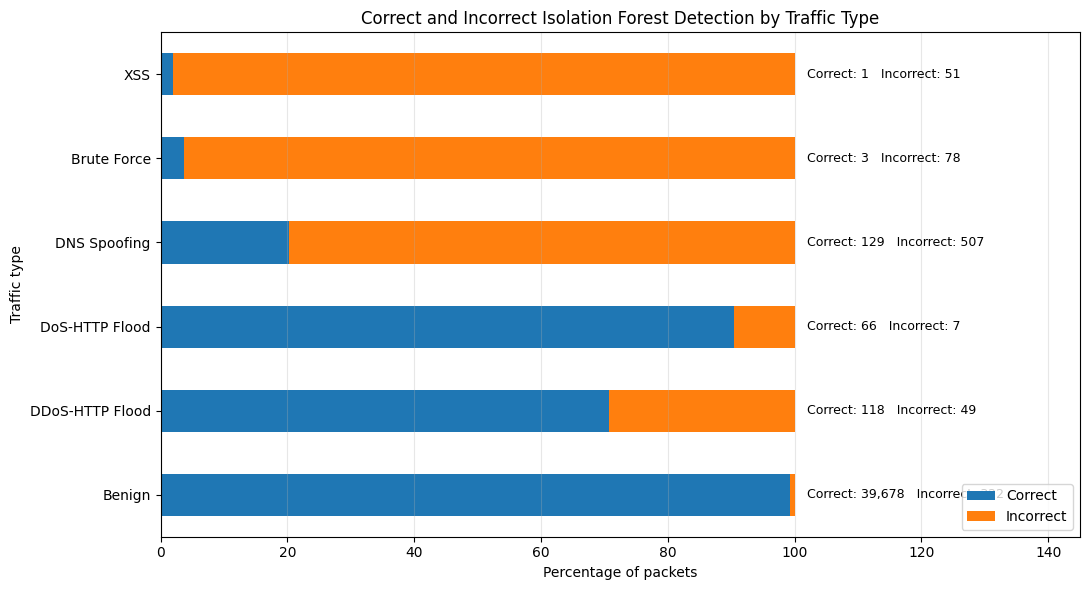

In [50]:
type_results = df_test_result[[ATTACK_COL]].copy()
type_results["y_true"] = y_test
type_results["y_pred"] = test_pred
type_results["correct"] = type_results["y_true"] == type_results["y_pred"]

result_by_type = type_results.groupby(ATTACK_COL).agg(total=("correct", "size"), correct=("correct", "sum"))
result_by_type["incorrect"] = result_by_type["total"] - result_by_type["correct"]
result_by_type["correct_rate"] = result_by_type["correct"] / result_by_type["total"] * 100
result_by_type["incorrect_rate"] = 100 - result_by_type["correct_rate"]

type_order = ["Benign", "DDoS-HTTP Flood", "DoS-HTTP Flood", "DNS Spoofing", "Brute Force", "XSS"]
result_by_type = result_by_type.reindex(type_order).dropna()

print("Classification results by traffic type:")
display(result_by_type[["total", "correct", "incorrect", "correct_rate"]].round(2))

### plot
plot_data = result_by_type[["correct_rate", "incorrect_rate"]]
ax = plot_data.plot(kind="barh", stacked=True, figsize=(11, 6))

for i, (_, row) in enumerate(result_by_type.iterrows()):
    count_text = f'Correct: {int(row["correct"]):,}   Incorrect: {int(row["incorrect"]):,}'
    ax.text(102, i, count_text, va="center", fontsize=9)

ax.set_xlim(0, 145)
ax.set_xlabel("Percentage of packets")
ax.set_ylabel("Traffic type")
ax.set_title("Correct and Incorrect Isolation Forest Detection by Traffic Type")
ax.legend(["Correct", "Incorrect"], loc="lower right")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

#### Confusion matrix visualization


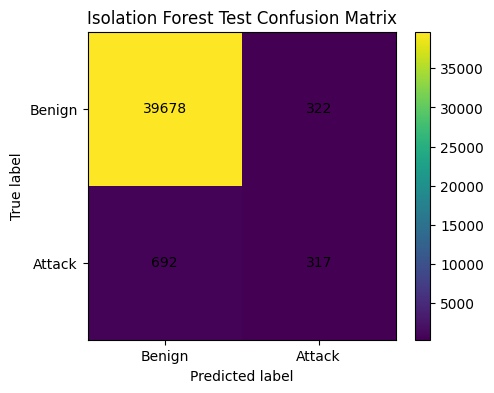

In [51]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.colorbar()
    plt.title(title)
    plt.xticks([0, 1], ["Benign", "Attack"])
    plt.yticks([0, 1], ["Benign", "Attack"])

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.show()


plot_confusion_matrix(y_test, test_pred, "Isolation Forest Test Confusion Matrix")

#### ROC curve


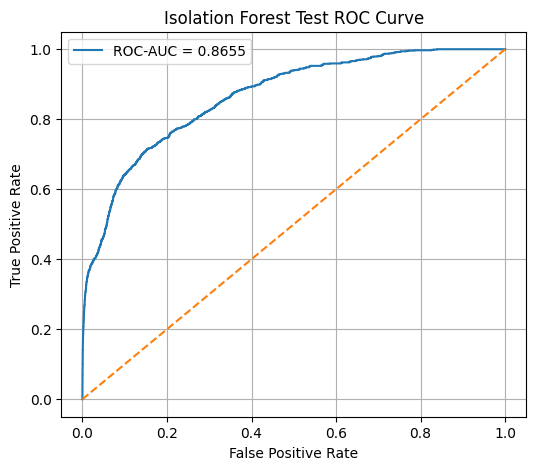

In [52]:
def plot_roc_curve(y_true, scores, title):
    fpr, tpr, _ = roc_curve(y_true, scores)
    auc_value = roc_auc_score(y_true, scores)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"ROC-AUC = {auc_value:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


plot_roc_curve(y_test, test_scores, "Isolation Forest Test ROC Curve")

#### Precision-recall curve


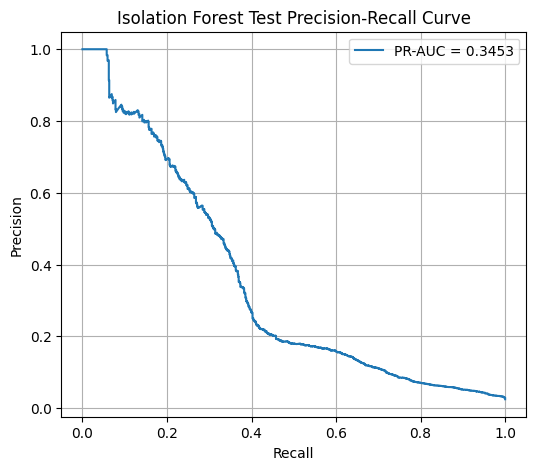

In [53]:
def plot_precision_recall_curve(y_true, scores, title):
    precision, recall, _ = precision_recall_curve(y_true, scores)
    pr_auc = average_precision_score(y_true, scores)

    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


plot_precision_recall_curve(y_test, test_scores, "Isolation Forest Test Precision-Recall Curve")

### PCA visualization

Use PCA to reduce the data to 2 dimensions to show clusters in 2D.

Explained variance: 0.9766952


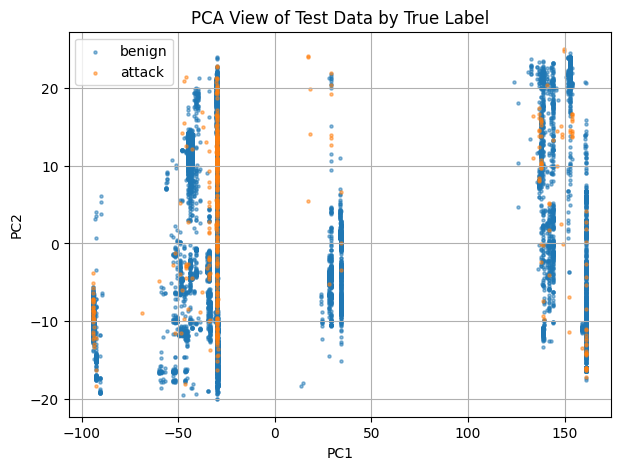

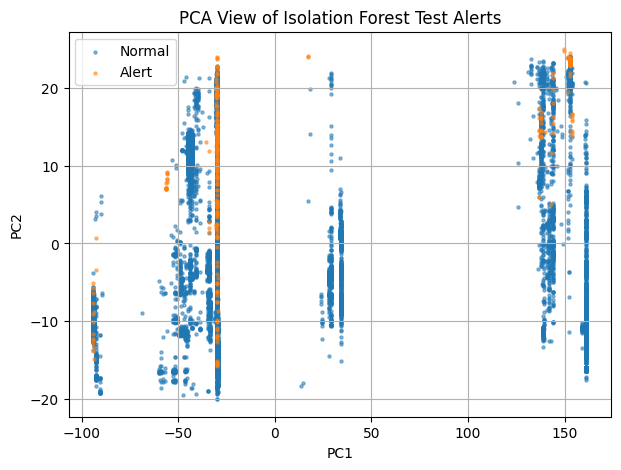

In [54]:
plot_size = min(20000, X_test.shape[0])
rng = np.random.default_rng(1)
plot_idx = rng.choice(X_test.shape[0], size=plot_size, replace=False)

pca = PCA(n_components=2, random_state=1)
X_2d = pca.fit_transform(X_test[plot_idx])

plot_df = pd.DataFrame({
    "PC1": X_2d[:, 0],
    "PC2": X_2d[:, 1],
    "binary_label": df_test_result.iloc[plot_idx][BINARY_COL].to_numpy(),
    "y_pred": df_test_result.iloc[plot_idx]["y_pred"].to_numpy(),
    "attack_type": df_test_result.iloc[plot_idx][ATTACK_COL].to_numpy()
})

print("Explained variance:", pca.explained_variance_ratio_.sum())

### true-label plot
plt.figure(figsize=(7, 5))
for label in ["benign", "attack"]:
    temp = plot_df[plot_df["binary_label"] == label]
    plt.scatter(temp["PC1"], temp["PC2"], s=5, alpha=0.5, label=label)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA View of Test Data by True Label")
plt.legend()
plt.grid(True)
plt.show()

### plot the Isolation Forest alerts
plt.figure(figsize=(7, 5))
for label in [0, 1]:
    temp = plot_df[plot_df["y_pred"] == label]
    name = "Normal" if label == 0 else "Alert"
    plt.scatter(temp["PC1"], temp["PC2"], s=5, alpha=0.5, label=name)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA View of Isolation Forest Test Alerts")
plt.legend()
plt.grid(True)
plt.show()

## Final Results

In [55]:
test_row = metrics_df.iloc[0]

print("Final Isolation Forest test results")
print("-----------------------------------")
print(f"Precision: {test_row['precision']:.4f}")
print(f"Recall: {test_row['recall']:.4f}")
print(f"F1-score: {test_row['f1']:.4f}")
print(f"ROC-AUC: {test_row['roc_auc']:.4f}")
print(f"PR-AUC: {test_row['pr_auc']:.4f}")
print(f"FPR: {test_row['fpr']:.4f}")
print(f"FNR: {test_row['fnr']:.4f}")
print(f"Test alerts: {int(test_row['alerts'])}")

### print the attack detection rates
print("\nDetection rate by attack type")
for attack_type in type_order[1:]:
    row = result_by_type.loc[attack_type]
    print(f"{attack_type}: {row['correct_rate']:.2f}%")

Final Isolation Forest test results
-----------------------------------
Precision: 0.4961
Recall: 0.3142
F1-score: 0.3847
ROC-AUC: 0.8655
PR-AUC: 0.3453
FPR: 0.0080
FNR: 0.6858
Test alerts: 639

Detection rate by attack type
DDoS-HTTP Flood: 70.66%
DoS-HTTP Flood: 90.41%
DNS Spoofing: 20.28%
Brute Force: 3.70%
XSS: 1.92%


### Analysis

Isolation Forest was used as the second packet-level unsupervised anomaly detector. The model was trained only on the training features, and packet labels were not passed into the fitting process. The data was divided into training, validation, and test sets so that preprocessing, hyperparameter selection, threshold selection, and final evaluation were performed separately.

Several Isolation Forest configurations were compared using validation PR-AUC and ROC-AUC. PR-AUC was used as the main selection metric because attacks make up only a small percentage of the dataset. The selected model used 400 trees, 4096 training samples per tree, and 50% of the available features for each tree.

The alert threshold was selected using the validation set. Several possible alert rates were tested, and the final threshold was chosen to maximize validation F1-score while keeping the validation false-positive rate below 1.5%. The same threshold was then applied to the test set without recalculation.

Performance was evaluated using precision, recall, F1-score, false-positive rate, false-negative rate, ROC-AUC, PR-AUC, confusion matrix, and per-attack detection rates. The traffic-type results are especially important because some attacks may produce clear packet-level anomalies, while others may look similar to benign traffic and require flow-level information in the second stage.
